### M^ evaluation

In [1]:
import os
import sys
from pathlib import Path

# Must be set before importing torch (or any module that imports it).
# Physical GPU index, or "" for CPU-only.
os.environ["CUDA_VISIBLE_DEVICES"] = input("GPU index: ")

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "settings.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "models" / "modified-classification"
ROOT = NOTEBOOK_DIR.parents[1]
for p in (ROOT, NOTEBOOK_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from _helpers import load_live_settings, load_run_settings, resolve_run_dir, unnormalize_metric_arrays

# Resolve run from live settings (DIR_NAME / OUTPUTS_DIR), then load that run's snapshot.
_live = load_live_settings()
# Optional override: RUN_DIR = NOTEBOOK_DIR / "outputs" / "..." / "20260709_144025"
RUN_DIR = resolve_run_dir(_live.OUTPUTS_DIR)
load_run_settings(RUN_DIR)
print(f"Loaded settings from {RUN_DIR / 'settings.py'}")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model_m import MetricPredictor
from model_t import TimestepPredictor
from _data import (
    df_to_metric_grids,
    grid_axes_from_df,
    load_splits_df,
    get_embeddings_by_sample,
    target_bounds,
    timestep_pairs_from_df,
)
from settings import *

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}  (CUDA_VISIBLE_DEVICES={os.environ.get('CUDA_VISIBLE_DEVICES', '')!r})")


Loaded settings from /data/home/mirick/ChordEdit/daniel-modified-classification-model/models/modified-classification/outputs/UltraEdit_Region_1000/20260721_091802/settings.py


/data/home/mirick/miniconda3/envs/chordedit/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda  (CUDA_VISIBLE_DEVICES='0')


In [2]:
# Split used by diagnostic plots below.
PLOT_SPLIT = "test"

def fig_title(subtitle: str, split: str | None = None) -> str:
    title = f"{subtitle} for $\\hat{{M}}$ on {METRICS_CSV.stem}, $\\delta={{{TARGET_T_DELTA:.2f}}}$"
    if split is not None:
        title += f" ({split})"
    return title


In [3]:
# Saved train/val/test splits from train_m (RUN_DIR set in imports cell).
splits = load_splits_df(RUN_DIR)
print(
    f"Run: {RUN_DIR.name}  "
    + "  ".join(
        f"{name}={len(df)} cells ({df[SAMPLE_ID_COL].nunique()} samples)"
        for name, df in splits.items()
    )
)

full_df = pd.concat(splits.values(), ignore_index=True)
T_START_VALUES, T_END_VALUES = grid_axes_from_df(full_df)
T_PAIRS = timestep_pairs_from_df(full_df)
N1, N2 = len(T_START_VALUES), len(T_END_VALUES)
CELLS = len(T_PAIRS)
print(f"Timestep pairs in data: {CELLS/(N1*N2)}")


Dropping 55 rows with missing values from /shared/ssd_30T/mirick/generated/ultra_edit/UltraEdit_Region_1000/id_to_metrics_ultraeditregion1000.csv
Run: 20260721_091802  train=43945 cells (799 samples)  val=5500 cells (100 samples)  test=5500 cells (100 samples)
Timestep pairs in data: 0.55


In [4]:
weights_path = RUN_DIR / "regressor_weights.pt"
ckpt = torch.load(weights_path, map_location=DEVICE, weights_only=False)
model = MetricPredictor(freeze_encoders=FREEZE_ENCODERS, device=DEVICE)
model.regressor.load_state_dict(ckpt["regressor_state_dict"])
model.regressor.set_target_stats(ckpt["target_mean"], ckpt["target_std"])
model.regressor.to(DEVICE).eval()

bounds = target_bounds()
t_predictor = TimestepPredictor(
    model,
    t_start_values=T_START_VALUES,
    t_end_values=T_END_VALUES,
    bounds=bounds,
)


Loading weights: 100%|██████████| 372/372 [00:00<00:00, 11168.16it/s]

Dropping 55 rows with missing values from /shared/ssd_30T/mirick/generated/ultra_edit/UltraEdit_Region_1000/id_to_metrics_ultraeditregion1000.csv


In [ ]:
def eval_split(df: pd.DataFrame) -> dict:
    sample_ids = sorted(df.sample_id.unique())
    embeddings = get_embeddings_by_sample(df.drop_duplicates("sample_id"), model, DEVICE)
    true_psnr, _ = df_to_metric_grids(df, sample_ids, T_START_VALUES, T_END_VALUES, PSNR_COL)
    true_clip, _ = df_to_metric_grids(df, sample_ids, T_START_VALUES, T_END_VALUES, CLIP_COL)
    pred_psnr = np.full_like(true_psnr, np.nan)
    pred_clip = np.full_like(true_clip, np.nan)
    for k, sid in enumerate(sample_ids):
        emb = embeddings[sid]
        # Only evaluate (t_start, t_end) pairs that exist in the metrics CSV.
        grid = t_predictor.predict_grid_from_emb(emb["img"], emb["mask"], emb["src"], emb["tar"], T_PAIRS)
        # M outputs min-max normalized targets, map back to raw PSNR / CLIP units.
        pred_psnr[k], pred_clip[k] = unnormalize_metric_arrays(grid.psnr_grid, grid.clip_grid, bounds)
    return {
        "sample_ids": sample_ids,
        "n_samples": len(sample_ids),
        "true_psnr": true_psnr,
        "true_clip": true_clip,
        "pred_psnr": pred_psnr,
        "pred_clip": pred_clip,
    }


split_results = {name: eval_split(df) for name, df in splits.items()}

true_psnr = split_results[PLOT_SPLIT]["true_psnr"]
true_clip = split_results[PLOT_SPLIT]["true_clip"]
pred_psnr = split_results[PLOT_SPLIT]["pred_psnr"]
pred_clip = split_results[PLOT_SPLIT]["pred_clip"]
SAMPLE_IDS = split_results[PLOT_SPLIT]["sample_ids"]
N_SAMPLES = split_results[PLOT_SPLIT]["n_samples"]


Loaded embeddings from /data/home/mirick/ChordEdit/daniel-modified-classification-model/models/modified-classification/outputs/.cache/embeddings/m_ultraeditregion1000.pt (799 samples)
Loaded embeddings from /data/home/mirick/ChordEdit/daniel-modified-classification-model/models/modified-classification/outputs/.cache/embeddings/m_ultraeditregion1000.pt (100 samples)
Loaded embeddings from /data/home/mirick/ChordEdit/daniel-modified-classification-model/models/modified-classification/outputs/.cache/embeddings/m_ultraeditregion1000.pt (100 samples)
test grids: (100, 10, 10)  (100 images, 55 labeled pairs / 100 axis cells)


In [6]:

"""
Global pointwise error — one table per metric (PSNR, CLIP), splits as rows.

For every labeled grid cell, compare M's predicted PSNR and CLIP to ground truth.

Metrics:
  - MAE:  average absolute error in raw units (PSNR dB, CLIP score).
  - RMSE: penalizes large outliers more than MAE.
  - R^2:   fraction of variance explained; 1.0 = perfect, 0 = predicting the mean.

Interpretation:
  - PSNR MAE ~1-3 dB with R^2 > 0.7  -> strong surrogate for structure fidelity.
  - CLIP MAE depends on score scale; compare across splits, not to PSNR directly.
  - R^2 near 0 or negative         -> model no better than the mean; not usable.
  - Train R^2 much higher than test -> overfitting; do not deploy this checkpoint.
  - Similar val and test tables    -> generalization estimate is reliable.
"""

from IPython.display import display

def _metrics(true_g, pred_g):
    # Grids are sparse under TARGET_T_DELTA; only score labeled (finite) cells.
    mask = np.isfinite(true_g) & np.isfinite(pred_g)
    e = pred_g[mask] - true_g[mask]
    t = true_g[mask]
    ss_res = float((e ** 2).sum())
    ss_tot = float(((t - t.mean()) ** 2).sum()) if t.size else 0.0
    return {
        "mae": float(np.abs(e).mean()) if e.size else float("nan"),
        "rmse": float(np.sqrt((e ** 2).mean())) if e.size else float("nan"),
        "r2": float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan"),
        "n_labeled": int(mask.sum()),
    }

split_summaries = {}
for col, label in zip(M_TARGET_COLS, (M_TARGET_LABELS[c] for c in M_TARGET_COLS)):
    true_key = "true_psnr" if col == PSNR_COL else "true_clip"
    pred_key = "pred_psnr" if col == PSNR_COL else "pred_clip"
    rows = {}
    for split_name in ("train", "val", "test"):
        r = split_results[split_name]
        rows[split_name] = _metrics(r[true_key], r[pred_key])
        rows[split_name]["samples"] = r["n_samples"]
        rows[split_name]["cells"] = rows[split_name].pop("n_labeled")
    table = pd.DataFrame.from_dict(rows, orient="index")[["samples", "cells", "mae", "rmse", "r2"]]
    split_summaries[col] = table
    print(fig_title(f"Global MAE / RMSE / R^2 — {label}"))
    display(table.style.format({"mae": "{:.3f}", "rmse": "{:.3f}", "r2": "{:.3f}"}))


Global MAE / RMSE / R^2 — PSNR-Unedited for $\hat{M}$ on id_to_metrics_ultraeditregion1000, $\delta={0.00}$


,samples,cells,mae,rmse,r2
train,799,43945,1.304,1.660,0.917
val,100,5500,2.055,2.626,0.783
test,100,5500,2.177,2.750,0.776


Global MAE / RMSE / R^2 — CLIP-Edited for $\hat{M}$ on id_to_metrics_ultraeditregion1000, $\delta={0.00}$


,samples,cells,mae,rmse,r2
train,799,43945,2.189,2.823,0.660
val,100,5500,3.288,4.147,0.263
test,100,5500,3.611,4.495,0.175


/tmp/ipykernel_3788838/3584032436.py:15: RuntimeWarning: Mean of empty slice
  scale = np.nanmean(np.abs(true_g), axis=0)
/tmp/ipykernel_3788838/3584032436.py:16: RuntimeWarning: Mean of empty slice
  rel_mae = np.nanmean(err, axis=0) / np.where(scale > 0, scale, np.nan)
/tmp/ipykernel_3788838/3584032436.py:15: RuntimeWarning: Mean of empty slice
  scale = np.nanmean(np.abs(true_g), axis=0)
/tmp/ipykernel_3788838/3584032436.py:16: RuntimeWarning: Mean of empty slice
  rel_mae = np.nanmean(err, axis=0) / np.where(scale > 0, scale, np.nan)


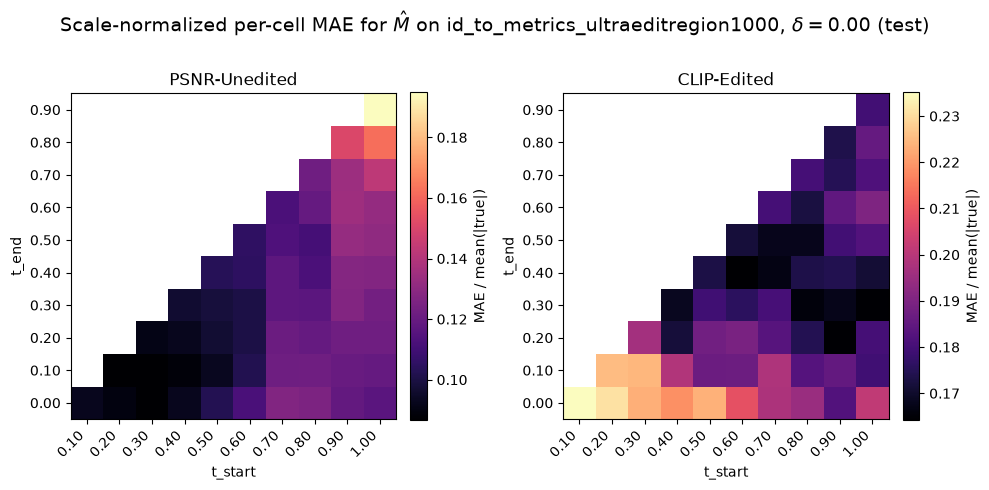

In [7]:
"""
Per-cell relative error

The following plot analyses the per-cell relative error of the model.
Because absolute MAE is dominated by high-magnitude cells (e.g.
high-PSNR closer to (0, 0)), we normalize by the cell's typical value.
"""

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, true_g, pred_g, title in [
    (axes[0], true_psnr, pred_psnr, M_TARGET_LABELS[PSNR_COL]),
    (axes[1], true_clip, pred_clip, M_TARGET_LABELS[CLIP_COL]),
]:
    err = np.abs(pred_g - true_g)
    scale = np.nanmean(np.abs(true_g), axis=0)
    rel_mae = np.nanmean(err, axis=0) / np.where(scale > 0, scale, np.nan)
    im = ax.imshow(np.ma.masked_invalid(rel_mae.T), origin="lower", cmap="magma", aspect="equal")
    ax.set_box_aspect(1)
    ax.set_title(title)
    ax.set_xlabel("t_start")
    ax.set_ylabel("t_end")
    ax.set_xticks(range(N1))
    ax.set_xticklabels([f"{t:.2f}" for t in T_START_VALUES], rotation=45, ha="right")
    ax.set_yticks(range(N2))
    ax.set_yticklabels([f"{t:.2f}" for t in T_END_VALUES])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MAE / mean(|true|)")
fig.suptitle(fig_title("Scale-normalized per-cell MAE", PLOT_SPLIT), fontsize=14)
plt.tight_layout()
plt.show()


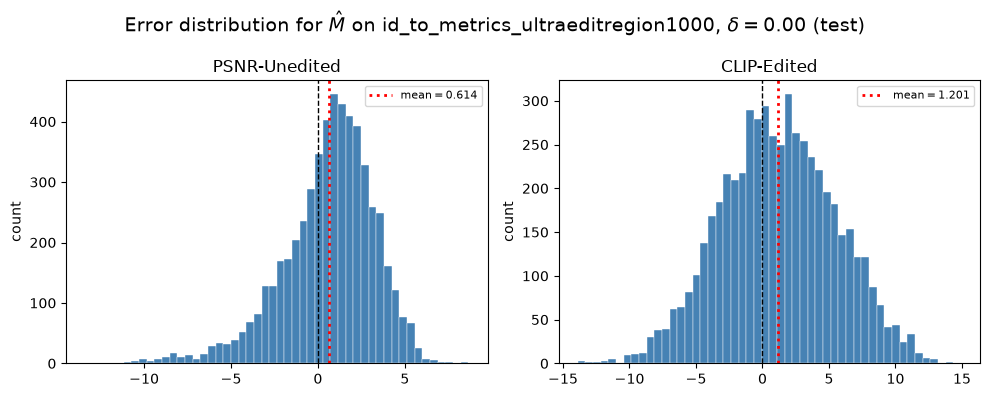

In [8]:
"""
Signed error distribution

Shows histograms of the prediction error (predicted value minus true
value) across all evaluation samples. By plotting these histograms
side-by-side, we can assess whether the model is systematically
overpredicting or underpredicting, the spread of errors (variance), and
the overall distribution shape for each metric.
"""

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, true_g, pred_g, title in [
    (axes[0], true_psnr, pred_psnr, M_TARGET_LABELS[PSNR_COL]),
    (axes[1], true_clip, pred_clip, M_TARGET_LABELS[CLIP_COL]),
]:
    err = (pred_g - true_g)[np.isfinite(true_g) & np.isfinite(pred_g)]
    ax.hist(err, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0.0, color="k", linestyle="--", linewidth=1.0)
    ax.axvline(np.mean(err), color="r", linestyle=":", linewidth=2.0, label=f"mean$={np.mean(err):.3f}$")
    ax.set_title(title)
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
fig.suptitle(fig_title("Error distribution", PLOT_SPLIT), fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3788838/935013122.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


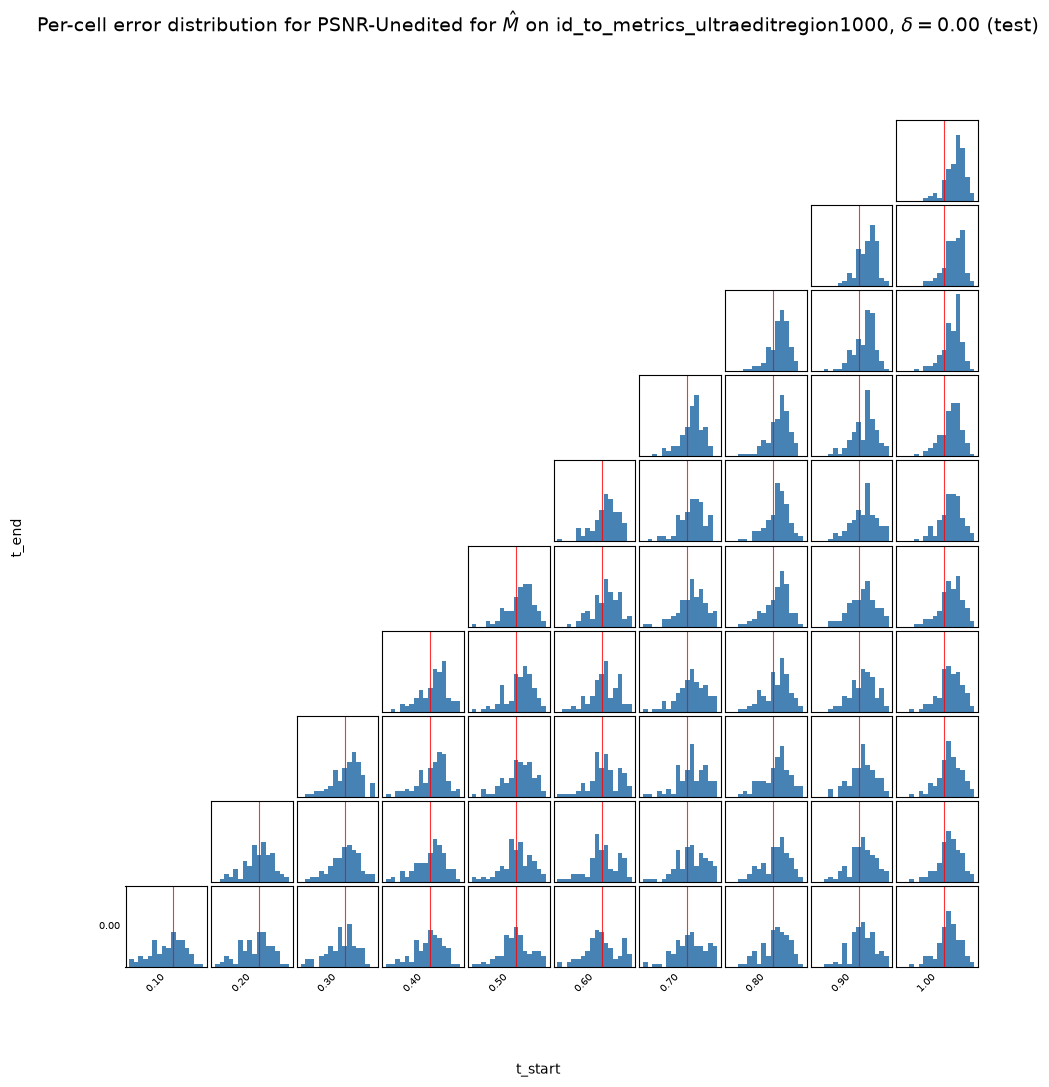

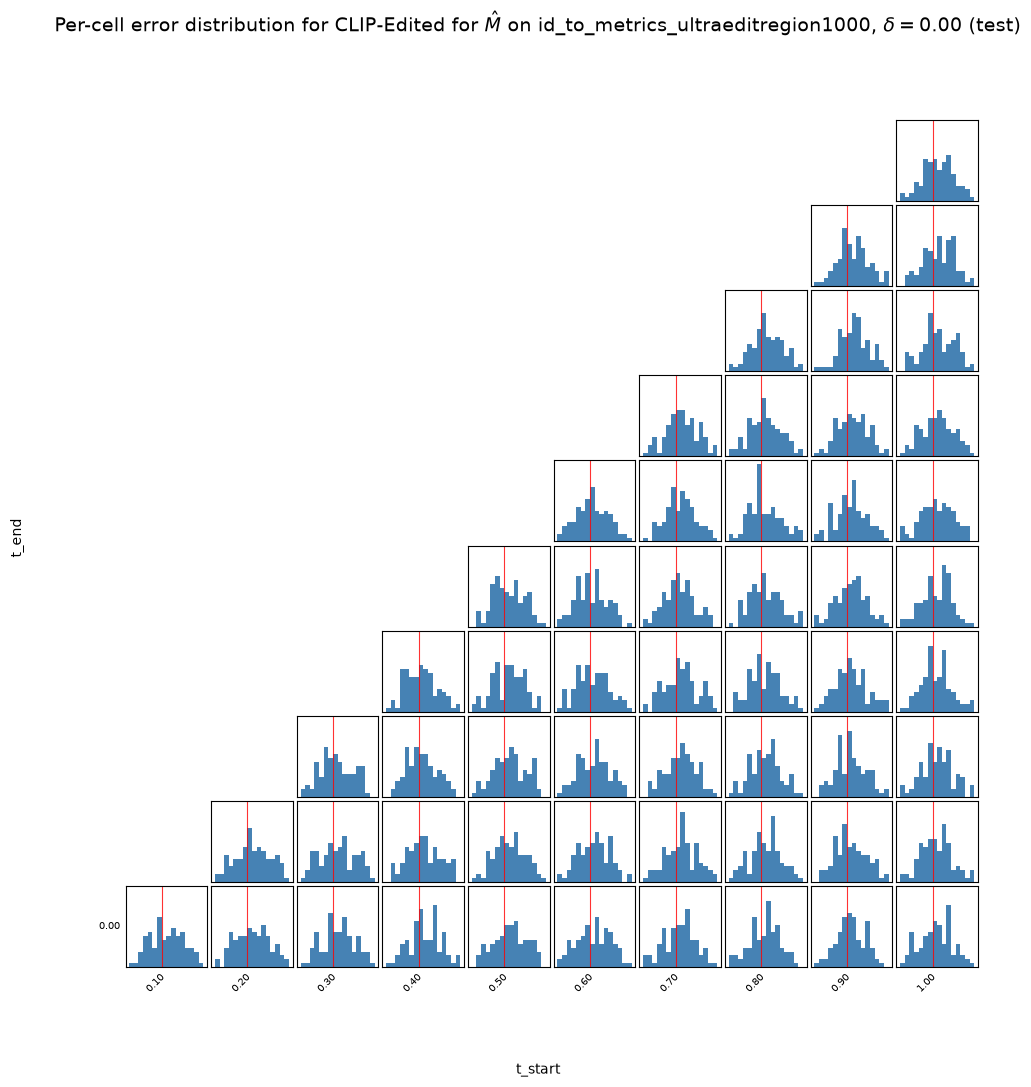

In [13]:
"""
Per-Cell Error Distribution

A breakdown of the previous plot, showing the per-cell error
distribution for each (t_start, t_end) cell.
"""


for true_g, pred_g, title in [
    (true_psnr, pred_psnr, M_TARGET_LABELS[PSNR_COL]),
    (true_clip, pred_clip, M_TARGET_LABELS[CLIP_COL]),
]:
    fig, axes = plt.subplots(
        N2, N1, figsize=(1.1 * N1, 1.1 * N2), sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.05, "hspace": 0.05},
    )
    # Shared bin edges from all labeled cells so panels are comparable.
    all_err = (pred_g - true_g)[np.isfinite(true_g) & np.isfinite(pred_g)]
    lo, hi = np.percentile(all_err, [1, 99]) if all_err.size else (-1.0, 1.0)
    bins = np.linspace(lo, hi, 17)

    for i in range(N1):
        for j in range(N2):
            # Row 0 at top in subplots; flip so lower-left is (t_start min, t_end min).
            ax = axes[N2 - 1 - j, i]
            e = pred_g[:, i, j] - true_g[:, i, j]
            e = e[np.isfinite(e)]
            if e.size == 0:
                ax.set_visible(False)
                continue
            ax.hist(e, bins=bins, color="steelblue", edgecolor="none")
            ax.axvline(0.0, color="r", linewidth=0.8, alpha=0.8)
            ax.set_xticks([])
            ax.set_yticks([])

    # Axis labels on outer edges only.
    for i, t in enumerate(T_START_VALUES):
        axes[N2 - 1, i].set_xlabel(f"{t:.2f}", fontsize=7, rotation=45, ha="right")
    for j, t in enumerate(T_END_VALUES):
        axes[N2 - 1 - j, 0].set_ylabel(f"{t:.2f}", fontsize=7, rotation=0, ha="right", va="center")

    fig.suptitle(fig_title(f"Per-cell error distribution for {title}", PLOT_SPLIT), fontsize=14)
    fig.supxlabel("t_start", fontsize=10)
    fig.supylabel("t_end", fontsize=10)
    plt.tight_layout()
    plt.show()


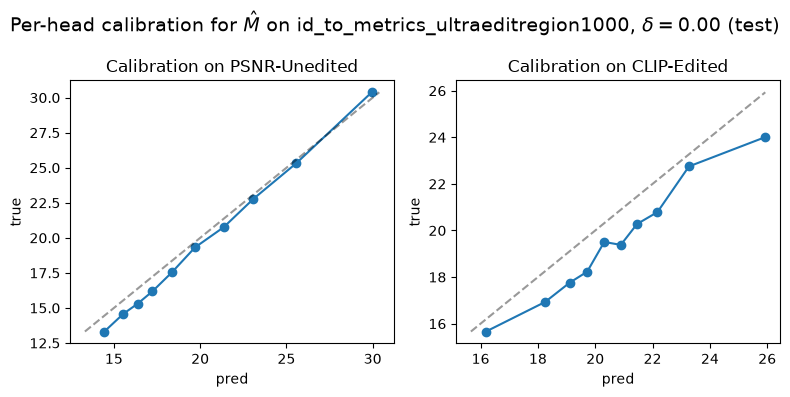

In [14]:

"""
Calibration Plot

Display per-head calibration plots for both PSNR and CLIP metrics. Each
plot compares the mean predicted values to the mean true values across
quantiles of model predictions, allowing for a visual assessment of how
well the model's predicted outputs align with actual targets.
"""


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, true_g, pred_g, title in [(axes[0], true_psnr, pred_psnr, M_TARGET_LABELS[PSNR_COL]), (axes[1], true_clip, pred_clip, M_TARGET_LABELS[CLIP_COL])]:
    labeled = np.isfinite(true_g) & np.isfinite(pred_g)
    p, t = pred_g[labeled], true_g[labeled]
    bins = np.quantile(p, np.linspace(0, 1, 11)); bins[0] -= 1e-6; bins[-1] += 1e-6
    idx = np.digitize(p, bins)
    bx, by = [], []
    for b in range(1, 11):
        mask = idx == b
        if mask.any():
            bx.append(p[mask].mean()); by.append(t[mask].mean())
    ax.plot(bx, by, "o-")
    lo, hi = min(bx + by), max(bx + by)
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4)
    ax.set_title(f"Calibration on {title}"); ax.set_xlabel("pred"); ax.set_ylabel("true")
fig.suptitle(fig_title("Per-head calibration", PLOT_SPLIT), fontsize=14)
plt.tight_layout(); plt.show()


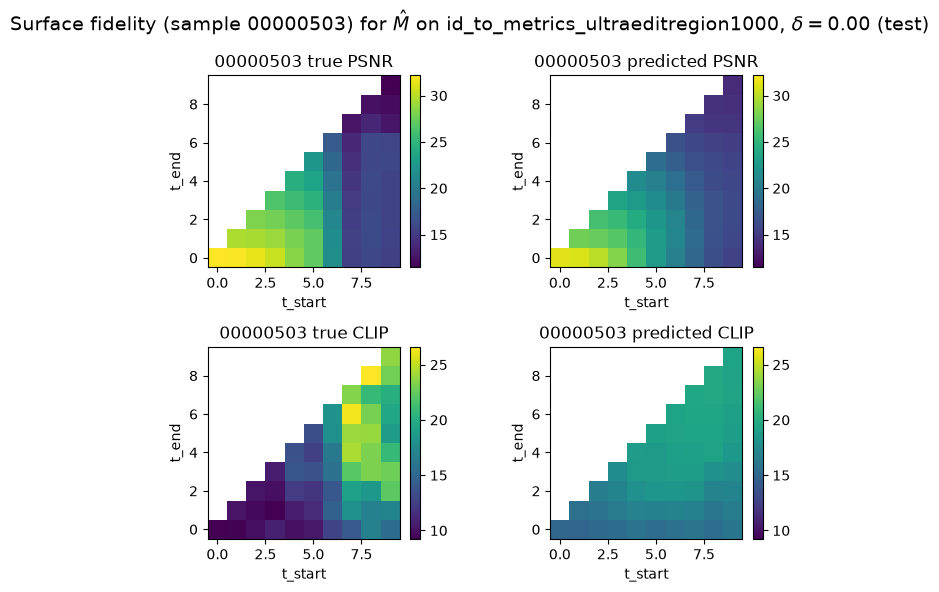

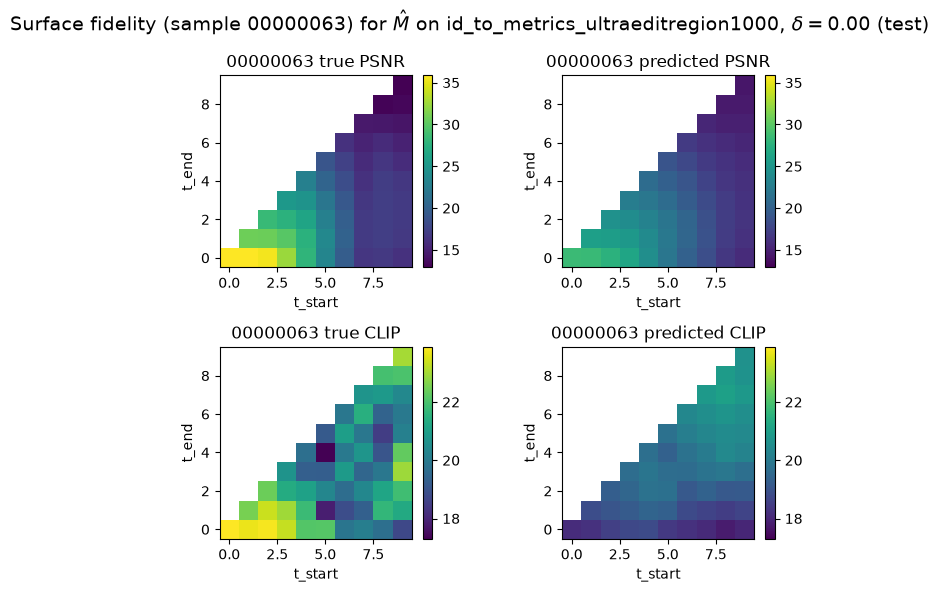

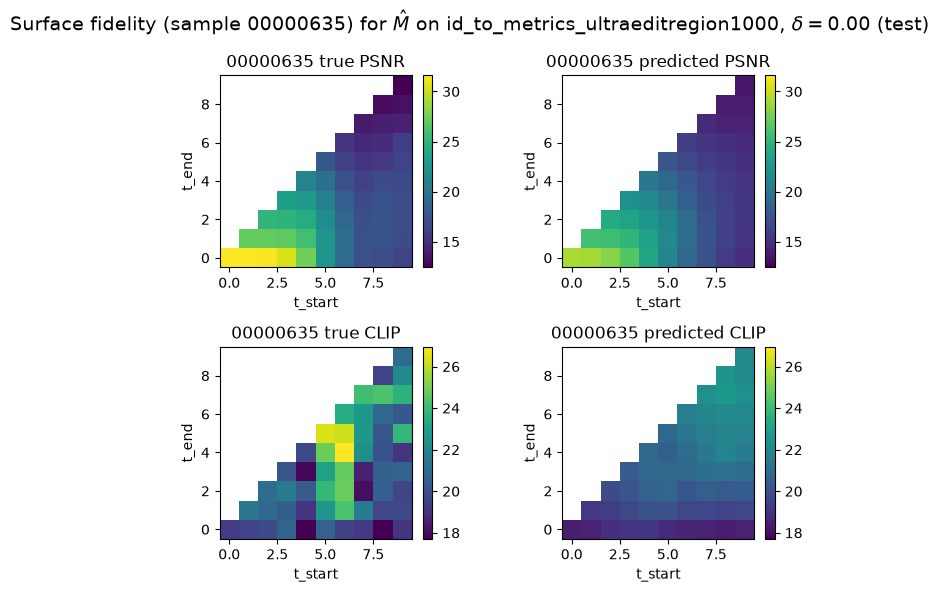

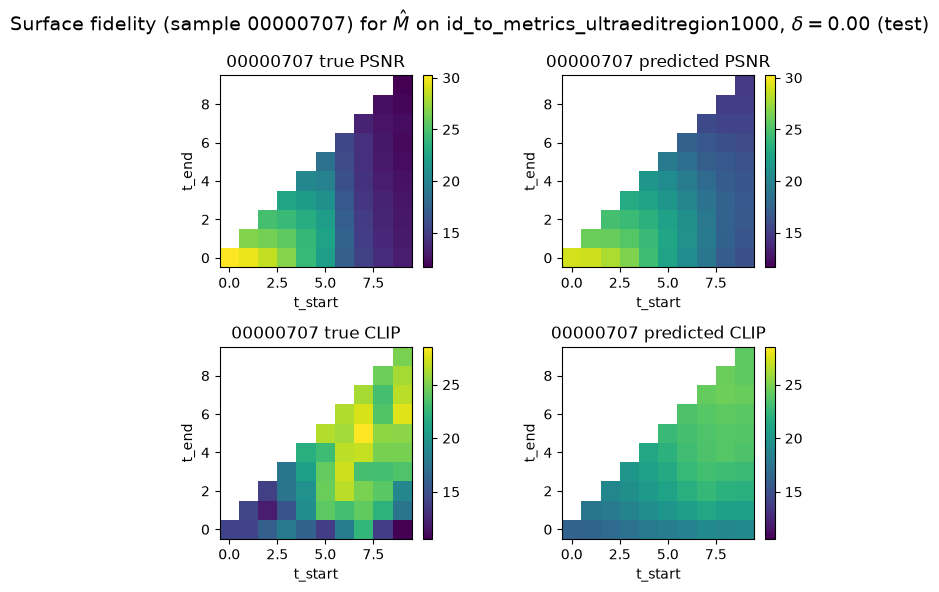

In [12]:

"""
Surface-shape Fidelity Plot

The following graphs display per-head surface-shape fidelity for both
PSNR and CLIP metrics. For each randomly selected example, the plot
shows true and predicted values as heatmaps across the (t_start, t_end)
grid. Each pair of heatmaps (true and predicted) for the same metric and
sample use a shared color scale, allowing for visual assessment of how
well the model's predicted surface matches the ground truth topology.
"""


rng = np.random.default_rng(SEED)
pick = rng.choice(N_SAMPLES, size=min(4, N_SAMPLES), replace=False)
for k in pick:
    fig, axes = plt.subplots(2, 2, figsize=(7, 6))
    panels = [
        (axes[0, 0], true_psnr[k], "true PSNR"),
        (axes[0, 1], pred_psnr[k], "predicted PSNR"),
        (axes[1, 0], true_clip[k], "true CLIP"),
        (axes[1, 1], pred_clip[k], "predicted CLIP"),
    ]
    scales = {
        "PSNR": (
            np.nanmin([np.nanmin(true_psnr[k]), np.nanmin(pred_psnr[k])]),
            np.nanmax([np.nanmax(true_psnr[k]), np.nanmax(pred_psnr[k])]),
        ),
        "CLIP": (
            np.nanmin([np.nanmin(true_clip[k]), np.nanmin(pred_clip[k])]),
            np.nanmax([np.nanmax(true_clip[k]), np.nanmax(pred_clip[k])]),
        ),
    }
    for ax, g, title in panels:
        metric = "PSNR" if "PSNR" in title else "CLIP"
        vmin, vmax = scales[metric]
        im = ax.imshow(np.ma.masked_invalid(g.T), origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_title(f"{SAMPLE_IDS[k]} {title}")
        ax.set_xlabel("t_start"); ax.set_ylabel("t_end")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(fig_title(f"Surface fidelity (sample {SAMPLE_IDS[k]})", PLOT_SPLIT), fontsize=14)
    plt.tight_layout(); plt.show()
